# Test of Time-independent Unitary Dynamics

The purpose of this notebook is to test and visually verify the correct implementation of unitary dynamics with time-independent Hamiltonian. We look at two qubits, evolving under a flip-flop coupling.

## 1. Imports

In [85]:
from qsim.dynamics import HamiltonianGenerator, ExponentialPropagator, Dynamics
from qsim.logging import Logger
from qsim.operator import I, sigmaZ, sigmaX
from qsim.state import Detector, DensityMatrix, Ket
from tqdm.auto import tqdm
import numpy as np

import math
import matplotlib.pyplot as plt

## 2. Configure Dynamics

In [86]:
# System dimension
d = 4

In [87]:
H = sigmaX.tensor(sigmaX)

In [88]:
def warnIfIllegitimate(state, t):
    if not state.isNormalised():
        print(f'Illegitimate State at t={t}')

In [89]:
generator = HamiltonianGenerator(H=H)
propagator = ExponentialPropagator(callbacks=None)

In [90]:
dynamics = Dynamics(propagator, generator)

## 3. Logger Setup

In [91]:
detector_qubit1 = Detector(sigmaZ, dims=(2,2), target_sites=(0,))
detector_qubit2 = Detector(sigmaZ, dims=(2,2), target_sites=(1,))

detector_joint = Detector(sigmaZ.tensor(sigmaZ))

In [92]:
logger_composite = Logger([detector_qubit1, detector_qubit2, detector_joint])
dynamics.addCallback(logger_composite.log)

## 4. Evolution

In [93]:
initial_state = DensityMatrix(np.array([[0,0,0,0],[0,1,0,0],[0,0,0,0],[0,0,0,0]]))
#initial_state = Ket(np.array([0,1,0,0]))

In [94]:
ts = np.linspace(0,15,300)

In [95]:
dynamics.evolve(initial_state, ts=list(ts))

DensityMatrix(dim=4)

## 5. Visualisation

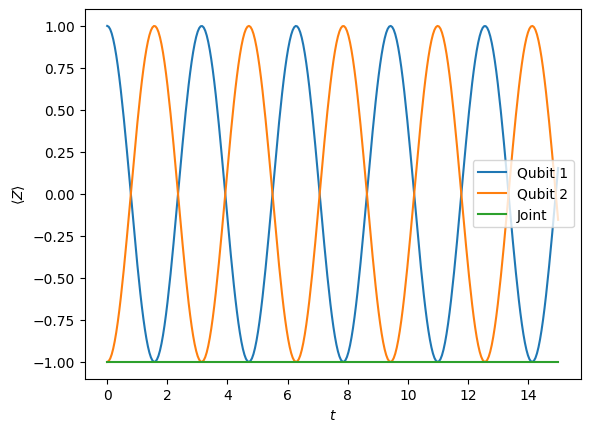

In [96]:
plt.plot(ts, logger_composite.observable_log[detector_qubit1].values(), label='Qubit 1')
plt.plot(ts, logger_composite.observable_log[detector_qubit2].values(), label = 'Qubit 2')
plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()

## 6. Heisenberg Evolution

In [97]:
generator = HamiltonianGenerator(H=H)
propagator = ExponentialPropagator()

In [98]:
heisenberg_dynamics = Dynamics(propagator, generator)

In [99]:
reduced_ts = ts
ops1 = [heisenberg_dynamics.evolveOperator(sigmaZ.tensor(I(2)), ts=[0], t0=t) for t in tqdm(reduced_ts)]
ops2 = [heisenberg_dynamics.evolveOperator(I(2).tensor(sigmaZ), ts=[0], t0=t) for t in tqdm(reduced_ts)]

100%|██████████| 300/300 [00:00<00:00, 53526.08it/s]


In [100]:


initial_state = DensityMatrix(np.array([[0,0,0,0],[0,1,0,0],[0,0,0,0],[0,0,0,0]]))


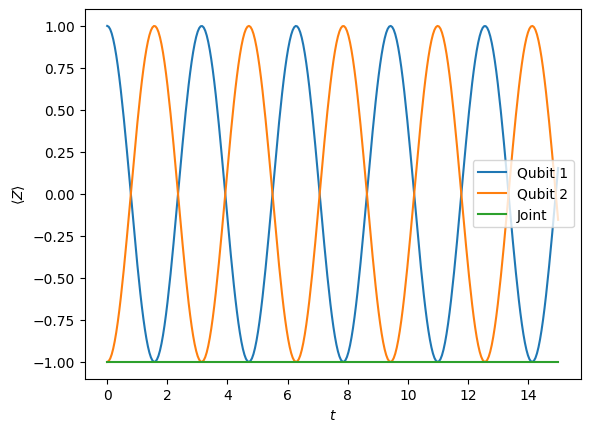

In [101]:
plt.plot(reduced_ts, [(op @ initial_state).trace() for op in ops1], label='Qubit 1')
plt.plot(reduced_ts, [(op @ initial_state).trace() for op in ops2], label='Qubit 2')
plt.plot(ts, logger_composite.observable_log[detector_joint].values(), label = 'Joint')
plt.ylabel(r'$\langle Z \rangle$')
plt.xlabel('$t$')
plt.legend()